Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

os.makedirs('../outputs/figures', exist_ok=True)
os.makedirs('../outputs/models', exist_ok=True)

sns.set_theme(style='whitegrid')
print("All imports successful")

All imports successful


Load Processed Data

In [2]:
X_train = np.load('../data/processed/X_train.npy')
X_test  = np.load('../data/processed/X_test.npy')
y_train = np.load('../data/processed/y_train.npy')
y_test  = np.load('../data/processed/y_test.npy')

FEATURES = joblib.load('../outputs/models/feature_names.pkl')

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (7148, 14)
X_test : (1788, 14)
y_train: (7148,)
y_test : (1788,)


Evaluation Helper Function

In [3]:
def evaluate_model(name, y_test, y_pred):
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    print(f"\n=== {name} ===")
    print(f"  MAE  : {mae:.2f}")
    print(f"  RMSE : {rmse:.2f}")
    print(f"  R²   : {r2:.4f}")
    return {'Model': name, 'MAE': round(mae, 2), 
            'RMSE': round(rmse, 2), 'R2': round(r2, 4)}

Model 1: Linear Regression

In [4]:
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

lr_results = evaluate_model("Linear Regression", y_test, lr_pred)
joblib.dump(lr, '../outputs/models/linear_regression.pkl')
print("Model saved.")


=== Linear Regression ===
  MAE  : 7886.13
  RMSE : 10174.83
  R²   : 0.3830
Model saved.


Model 2: Random Forest

In [5]:
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

rf_results = evaluate_model("Random Forest", y_test, rf_pred)
joblib.dump(rf, '../outputs/models/random_forest.pkl')
print("Model saved.")


=== Random Forest ===
  MAE  : 6092.16
  RMSE : 8266.21
  R²   : 0.5928
Model saved.


Model 3: XGBoost

In [6]:
xgb = XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)

xgb_results = evaluate_model("XGBoost", y_test, xgb_pred)
joblib.dump(xgb, '../outputs/models/xgboost.pkl')
print("Model saved.")


=== XGBoost ===
  MAE  : 6253.35
  RMSE : 8392.79
  R²   : 0.5802
Model saved.


Comparison Table

In [7]:
results_df = pd.DataFrame([lr_results, rf_results, xgb_results])
results_df = results_df.sort_values('R2', ascending=False).reset_index(drop=True)
results_df.index += 1
print("\n=== Model Comparison ===")
print(results_df.to_string())


=== Model Comparison ===
               Model      MAE      RMSE      R2
1      Random Forest  6092.16   8266.21  0.5928
2            XGBoost  6253.35   8392.79  0.5802
3  Linear Regression  7886.13  10174.83  0.3830


Comparison Bar Chart

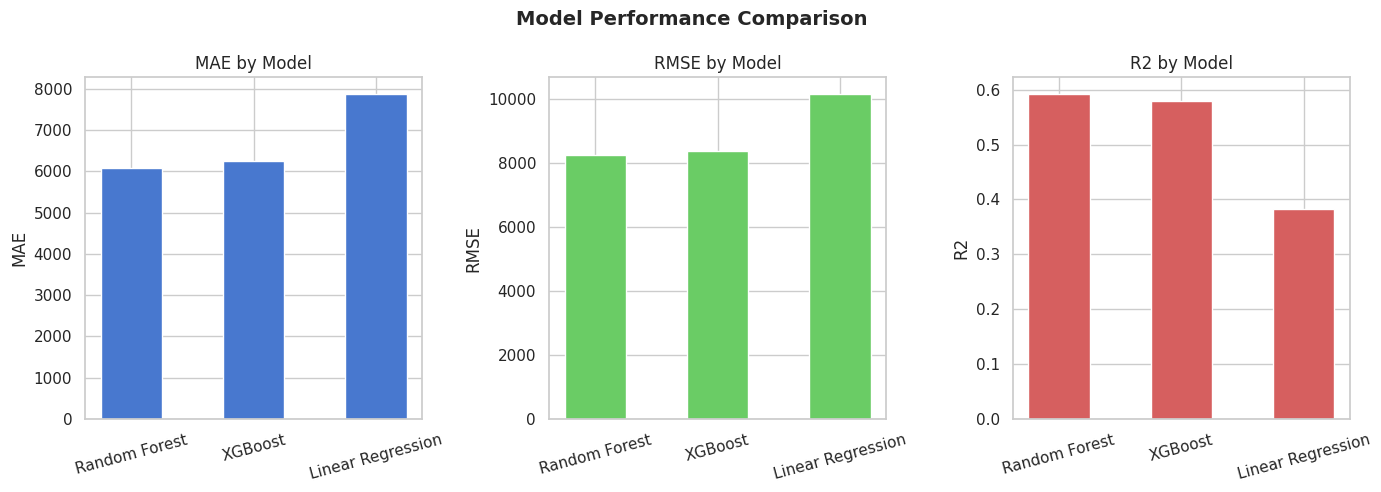

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
metrics = ['MAE', 'RMSE', 'R2']
colors  = ['#4878CF', '#6ACC65', '#D65F5F']

for i, metric in enumerate(metrics):
    axes[i].bar(results_df['Model'], results_df[metric], color=colors[i], width=0.5)
    axes[i].set_title(f'{metric} by Model')
    axes[i].set_ylabel(metric)
    axes[i].tick_params(axis='x', rotation=15)

plt.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/model_comparison.png', dpi=150)
plt.show()

Actual vs Predicted Plot

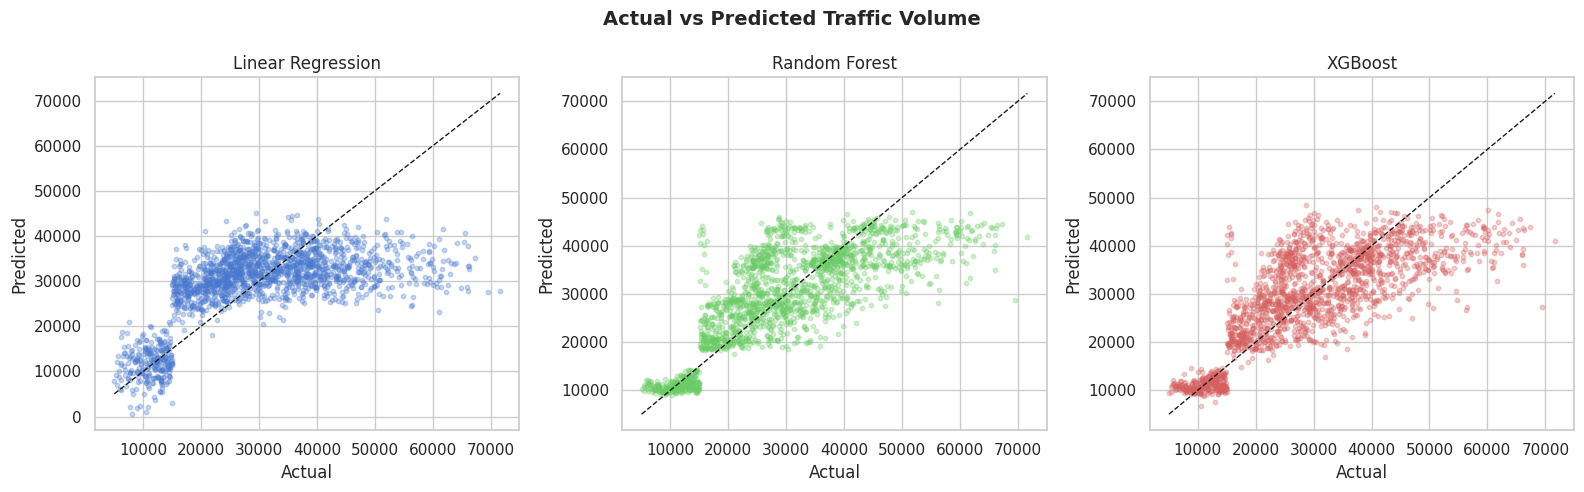

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
models  = ['Linear Regression', 'Random Forest', 'XGBoost']
preds   = [lr_pred, rf_pred, xgb_pred]
colors  = ['#4878CF', '#6ACC65', '#D65F5F']

for i, (name, pred, color) in enumerate(zip(models, preds, colors)):
    axes[i].scatter(y_test, pred, alpha=0.3, color=color, s=10)
    axes[i].plot([y_test.min(), y_test.max()],
                 [y_test.min(), y_test.max()],
                 'k--', linewidth=1)
    axes[i].set_title(name)
    axes[i].set_xlabel('Actual')
    axes[i].set_ylabel('Predicted')

plt.suptitle('Actual vs Predicted Traffic Volume', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/actual_vs_predicted.png', dpi=150)
plt.show()

Feature Importance (XGBoost)


/tmp/ipykernel_57520/2017700398.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Importance', y='Feature', palette='Blues_r')


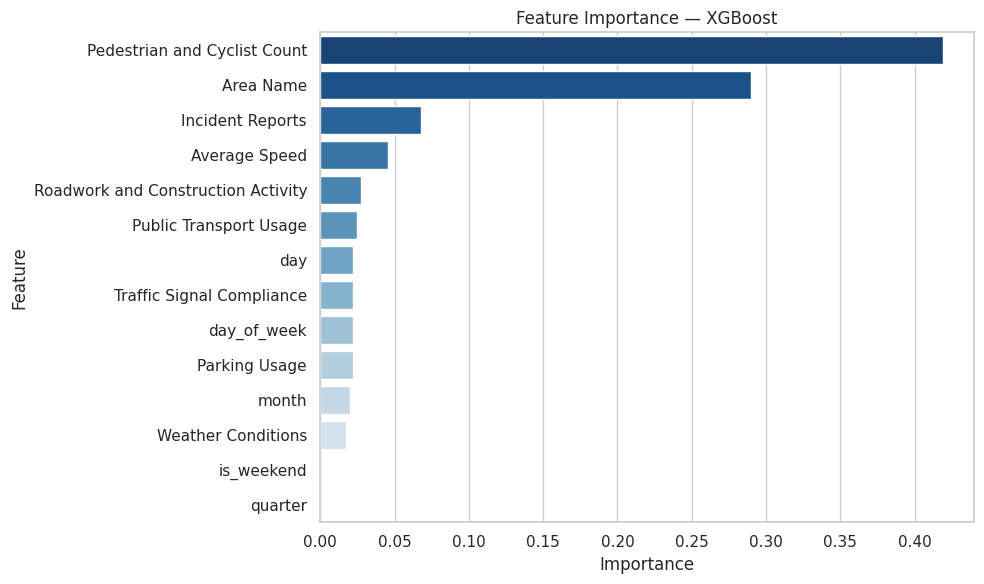

                           Feature  Importance
      Pedestrian and Cyclist Count    0.419054
                         Area Name    0.290074
                  Incident Reports    0.067568
                     Average Speed    0.045688
Roadwork and Construction Activity    0.027200
            Public Transport Usage    0.024601
                               day    0.022280
         Traffic Signal Compliance    0.022156
                       day_of_week    0.022118
                     Parking Usage    0.021907
                             month    0.020092
                Weather Conditions    0.017262
                        is_weekend    0.000000
                           quarter    0.000000


In [10]:
importance_df = pd.DataFrame({
    'Feature'   : FEATURES,
    'Importance': xgb.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='Blues_r')
plt.title('Feature Importance — XGBoost')
plt.tight_layout()
plt.savefig('../outputs/figures/feature_importance.png', dpi=150)
plt.show()

print(importance_df.to_string(index=False))

Save Best Model for Flask


In [11]:
# Pick best model based on R2
best_name  = results_df.iloc[0]['Model']
best_model = {'Linear Regression': lr,
              'Random Forest': rf,
              'XGBoost': xgb}[best_name]

joblib.dump(best_model, '../outputs/models/best_model.pkl')
print(f"Best model : {best_name}")
print(f"Saved to   : outputs/models/best_model.pkl")
print(f"\nThis is what your Flask backend will load.")

Best model : Random Forest
Saved to   : outputs/models/best_model.pkl

This is what your Flask backend will load.
